### **Decision Tree for Classification**
Example using 'play tennis' dataset

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree, metrics
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

In [4]:
### play tennis dataset
df = pd.read_csv('play_tennis_ready.csv')
df

,ID,Weather,Temperature,Humidity,Windy,Play
0,1,Sunny,Hot,High,False,No
1,2,Sunny,Hot,High,True,No
2,3,Overcast,Hot,High,False,Yes
3,4,Rain,Mild,High,False,Yes
4,5,Rain,Cool,Normal,False,Yes
5,6,Rain,Cool,Normal,True,No
6,7,Overcast,Cool,Normal,True,Yes
7,8,Sunny,Mild,High,False,No
8,9,Sunny,Cool,Normal,False,Yes
9,10,Rain,Mild,Normal,False,Yes


Tree depth: 4
Number of leaves: 7


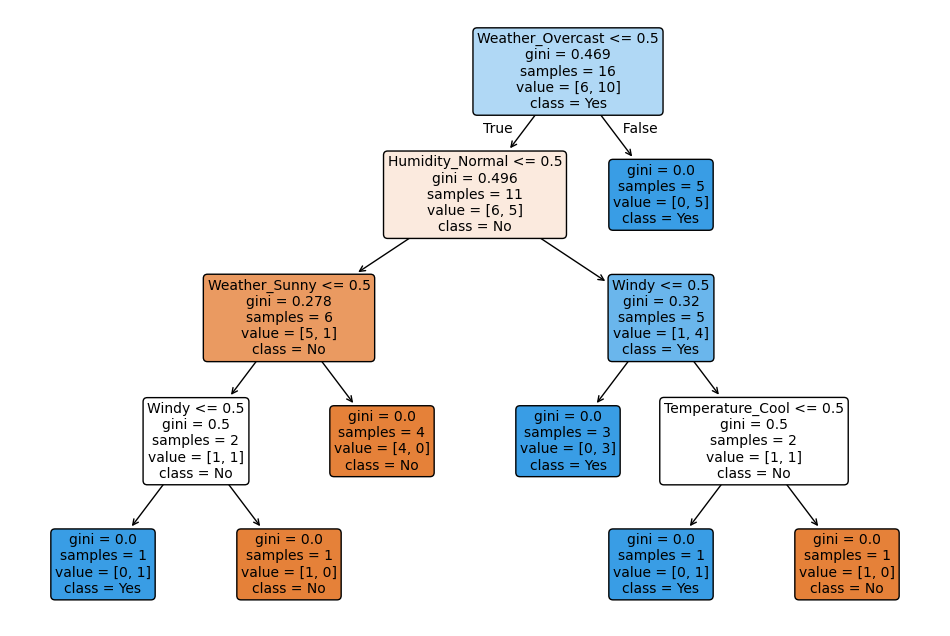

In [6]:
### one-hot encode the categorical input attributes
X = pd.get_dummies(
    df[['Weather', 'Temperature', 'Humidity', 'Windy']],
    drop_first=False
)

### encode the target variable
y = df['Play'].map({'No': 0, 'Yes': 1})

### classifier
clf = DecisionTreeClassifier(criterion='gini') # switch to 'entropy' for information gain metric
clf.fit(X, y)

### tree information
print("Tree depth:", clf.get_depth())
print("Number of leaves:", clf.get_n_leaves())

### plot the decision tree
plt.figure(figsize=(12,8))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

In [8]:
### to see the tree as text instead of a figure
rules = export_text(clf, feature_names=list(X.columns))
print(rules)

|--- Weather_Overcast <= 0.50
|   |--- Humidity_Normal <= 0.50
|   |   |--- Weather_Sunny <= 0.50
|   |   |   |--- Windy <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Windy >  0.50
|   |   |   |   |--- class: 0
|   |   |--- Weather_Sunny >  0.50
|   |   |   |--- class: 0
|   |--- Humidity_Normal >  0.50
|   |   |--- Windy <= 0.50
|   |   |   |--- class: 1
|   |   |--- Windy >  0.50
|   |   |   |--- Temperature_Cool <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Temperature_Cool >  0.50
|   |   |   |   |--- class: 0
|--- Weather_Overcast >  0.50
|   |--- class: 1

